# CS2810 HW2: Inverse Kinematics and Hand-Eye Calibration

This is an individual assignment. You may discuss with classmates but you must write your own code and submit your own files. If you use external references, you must cite your sources.

**Instructions:**

1. Complete all `TODO` sections in this notebook. Run all cells and ensure no errors.
   
2. You must submit two files to the Gradescope:
   - An exported PDF version of the notebook. And ensure important content (including the modified code, outputs, and markdown) is visible in the exported PDF.
   - A zip file containing:
     - The completed Jupyter Notebook (.ipynb).
     - The modified MJCF files ("scene_eye_in_hand.xml", "panda_eye_to_hand.xml") that you used for the hand-eye calibration.
     - Any additional files you created or modified as part of this assignment (e.g., helper scripts, data files). Make sure to include all necessary files for your code to run correctly.
   

In [1]:
# Install necessary libraries (uncomment if running locally/colab)
# %pip install mujoco==3.5.0 matplotlib opencv-python-headless numpy tqdm

from typing import List, Tuple, Dict

import os
if "MUJOCO_GL" not in os.environ and not os.environ.get("DISPLAY"):
    os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import mujoco
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

## Part 1: Inverse Kinematics (IK)

In this section, you will implement an Inverse Kinematics solver. This is a crucial prerequisite for moving the robotic arm to collect hand-eye calibration data. (*Hint*: A mujoco reference: https://github.com/kevinzakka/mjctrl/blob/main/diffik.py)

The `IKTester` class is provided to help you evaluate the accuracy of your IK solver.

In [2]:
class IKTester:
    """Utility class for evaluating inverse kinematics solvers."""

    def __init__(
        self,
        model: mujoco.MjModel,
        data: mujoco.MjData,
        eef_name: str = "attachment_site",
        eef_elem_type: str = "site",
    ):
        self.model = model
        self.data = data
        self.eef_name = eef_name
        self.eef_elem_type = eef_elem_type

    def get_eef_pose(self):
        if self.eef_elem_type == "body":
            idx = self.model.body(self.eef_name).id
            rot = self.data.xmat[idx].reshape(3, 3)
            pos = self.data.xpos[idx]
        elif self.eef_elem_type == "site":
            idx = self.model.site(self.eef_name).id
            rot = self.data.site_xmat[idx].reshape(3, 3)
            pos = self.data.site_xpos[idx]
        else:
            raise ValueError(f"Unknown element type: {self.eef_elem_type}")
        return np.array(rot), np.array(pos)

    def evaluate(
        self,
        ik_func: callable,
        trials: int = 100,
        rot_thresh: float = 1.0,
        pos_thresh: float = 1e-3,
        seed: int = 2810,
    ):
        """Evaluate the IK solver by sampling random joint configurations and checking if the predicted joints can achieve the same end-effector pose.
        Args:
            ik_func: A function that takes in target position and rotation, and outputs predicted joint angles.
            trials: Number of random configurations to test.
            rot_thresh: Rotation error threshold in degrees.
            pos_thresh: Position error threshold in meters.
            seed: Random seed for reproducibility.
        """
        print(f"=== Test IK for {trials} trials with seed={seed} ===")

        jnt_range = self.model.jnt_range  # [nq, 2]
        if mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_KEY, "home") != -1:
            q0 = self.model.key("home").qpos
        else:
            q0 = np.zeros(self.model.nq)

        rng = np.random.RandomState(seed)
        correct = 0

        try:
            import tqdm

            pbar = tqdm.tqdm
        except ImportError:
            pbar = lambda x: x

        for _ in pbar(range(trials)):
            q = rng.uniform(jnt_range[:, 0], jnt_range[:, 1])
            self.data.qpos[:] = q
            mujoco.mj_forward(self.model, self.data)
            target_rot, target_pos = self.get_eef_pose()

            # Reset to zero/home position to avoid leaking
            self.data.qpos[:] = q0
            mujoco.mj_forward(self.model, self.data)

            # Test the IK solver
            _q = ik_func(target_pos, target_rot)

            # Convert revolute joint angles into [-pi, pi]
            _q = np.array(_q)
            _q[:2] = np.mod(_q[:2] + np.pi, 2 * np.pi) - np.pi

            # Check joint limits
            eps = 1e-3
            if np.any(_q < jnt_range[:, 0] - eps) or np.any(_q > jnt_range[:, 1] + eps):
                print("IK solution is out of joint limits, skipping...")
                continue

            # Run FK on predicted joints
            self.data.qpos[:] = _q
            mujoco.mj_forward(self.model, self.data)
            pred_rot, pred_pos = self.get_eef_pose()

            pos_diff = np.linalg.norm(target_pos - pred_pos)
            angle_diff = np.arccos(
                np.clip(0.5 * (np.sum(pred_rot * target_rot) - 1), -1, 1)
            )
            angle_diff = np.rad2deg(angle_diff)

            if pos_diff < pos_thresh and angle_diff < rot_thresh:
                correct += 1

        accuracy = correct / trials
        print(f"accuracy: {accuracy:.3f}")
        print("----------------------------------------")

In [3]:
class IKSolver:
    def __init__(self, model: mujoco.MjModel, data: mujoco.MjData, eef_name: str="attachment_site", eef_elem_type: str = "site"):
        if eef_elem_type != "site":
            raise ValueError("This solver is implemented for site-based end-effectors.")

        self.model = model
        self.data = data
        self.eef_name = eef_name
        self.eef_elem_type = eef_elem_type
        self.eef_id = self.model.site(self.eef_name).id
        self.joint_limits = self.model.jnt_range.copy()
        self.home_qpos = self.model.key("home").qpos.copy() if mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_KEY, "home") != -1 else np.zeros(self.model.nq)

        rng = np.random.RandomState(2810)
        self.restart_seeds = [self.home_qpos.copy()]
        for _ in range(24):
            self.restart_seeds.append(rng.uniform(self.joint_limits[:, 0], self.joint_limits[:, 1]))

    @staticmethod
    def _rotation_error(current_rot: np.ndarray, target_rot: np.ndarray) -> np.ndarray:
        return 0.5 * (
            np.cross(current_rot[:, 0], target_rot[:, 0])
            + np.cross(current_rot[:, 1], target_rot[:, 1])
            + np.cross(current_rot[:, 2], target_rot[:, 2])
        )

    @staticmethod
    def _rotation_angle_deg(rot_a: np.ndarray, rot_b: np.ndarray) -> float:
        delta = rot_a @ rot_b.T
        cos_angle = np.clip((np.trace(delta) - 1.0) / 2.0, -1.0, 1.0)
        return float(np.rad2deg(np.arccos(cos_angle)))

    def _solve_from_seed(
        self,
        target_pos: np.ndarray,
        target_rot: np.ndarray,
        q_init: np.ndarray,
        max_iters: int = 250,
        damping: float = 1e-2,
        step_size: float = 0.7,
        tol_pos: float = 1e-5,
        tol_rot: float = 1e-5,
    ):
        q = np.clip(np.asarray(q_init, dtype=float).copy(), self.joint_limits[:, 0], self.joint_limits[:, 1])
        jacp = np.zeros((3, self.model.nv))
        jacr = np.zeros((3, self.model.nv))
        eye6 = np.eye(6)

        for _ in range(max_iters):
            self.data.qpos[:] = q
            mujoco.mj_forward(self.model, self.data)

            current_pos = self.data.site_xpos[self.eef_id].copy()
            current_rot = self.data.site_xmat[self.eef_id].reshape(3, 3).copy()
            pos_err = target_pos - current_pos
            rot_err = self._rotation_error(current_rot, target_rot)

            if np.linalg.norm(pos_err) < tol_pos and np.linalg.norm(rot_err) < tol_rot:
                break

            mujoco.mj_jacSite(self.model, self.data, jacp, jacr, self.eef_id)
            jacobian = np.vstack([jacp, jacr])
            error = np.concatenate([pos_err, rot_err])
            dq = jacobian.T @ np.linalg.solve(jacobian @ jacobian.T + (damping ** 2) * eye6, error)

            q = np.clip(q + step_size * dq, self.joint_limits[:, 0], self.joint_limits[:, 1])

        self.data.qpos[:] = q
        mujoco.mj_forward(self.model, self.data)
        final_pos = self.data.site_xpos[self.eef_id].copy()
        final_rot = self.data.site_xmat[self.eef_id].reshape(3, 3).copy()
        final_pos_err = np.linalg.norm(target_pos - final_pos)
        final_rot_err_deg = self._rotation_angle_deg(final_rot, target_rot)
        return q.copy(), final_pos_err, final_rot_err_deg

    def __call__(self, target_pos, target_rot, **kwargs):
        """Solve the joint angles for the given target end-effector pose.

        Args:
            target_pos: (3,) array of the target end-effector position.
            target_rot: (3, 3) array of the target end-effector rotation matrix.

        Returns:
            q: (nq,) array of the predicted joint angles.
        """
        target_pos = np.asarray(target_pos, dtype=float).reshape(3)
        target_rot = np.asarray(target_rot, dtype=float).reshape(3, 3)

        candidate_seeds = [self.data.qpos.copy()] + self.restart_seeds
        best_q = self.home_qpos.copy()
        best_score = np.inf

        for seed in candidate_seeds:
            q, pos_err, rot_err_deg = self._solve_from_seed(target_pos, target_rot, seed, **kwargs)
            score = pos_err + 1e-3 * rot_err_deg
            if score < best_score:
                best_score = score
                best_q = q
            if pos_err < 1e-3 and rot_err_deg < 1.0:
                return q

        return best_q

In [4]:
def load_panda_model(xml_path="franka_emika_panda/panda_nohand.xml"):
    model = mujoco.MjModel.from_xml_path(xml_path)
    data = mujoco.MjData(model)
    return model, data

# Load the MuJoCo model
model, data = load_panda_model()

ik_solver = IKSolver(model, data)
tester = IKTester(model, data)
tester.evaluate(ik_solver, trials=100)

=== Test IK for 100 trials with seed=2810 ===


  0%|          | 0/100 [00:00<?, ?it/s]

  8%|▊         | 8/100 [00:00<00:01, 69.54it/s]

 15%|█▌        | 15/100 [00:00<00:02, 30.90it/s]

 30%|███       | 30/100 [00:00<00:01, 60.69it/s]

...

 86%|████████▌ | 86/100 [00:02<00:00, 18.60it/s]

 96%|█████████▌| 96/100 [00:03<00:00, 23.47it/s]

100%|██████████| 100/100 [00:03<00:00, 17.74it/s]

100%|██████████| 100/100 [00:03<00:00, 27.16it/s]

accuracy: 1.000
----------------------------------------


### Rubric

The score is calculated strictly proportionally based on the success rate (SR). A trial is considered a "success" by the tester if the position error is $< 1$ mm and the rotation error is $< 1.0^\circ$. 

**Scoring Formula** The score highly depends on the success rate `accuracy` (SR) of the IK solver: 
1. If $SR \leq 80\%$, you receive no points.
2. If $80\% < SR \leq 90%$, you get `Score = 20 * accuracy`.
3. If $90\% < SR \leq 95\%$, you get `Score = 20`.
4. If $95\% < SR < 100\%$, you get `Score = 25`.
5. If $SR == 100\%$, you get full points `Score = 30`. 


## Part 2: Hand-Eye Calibration (Eye-in-Hand)

For this section, the camera is rigidly mounted on the robot's end-effector (gripper). You will solve the classical $AX = XB$ problem, where $X$ is the unknown hand-eye transformation ($T_{cam2gripper}$).

We have provided the generic environment class `PandaEnv` to help you interface with the simulation.

**You need to modify the MJCF file ("scene_eye_in_hand.xml") to place the calibration pattern in the scene. You can use any calibration pattern you like, but make sure to provide accurate 3D coordinates for the pattern points. You can add your custom calibration pattern as a mesh or a texture (additional file is allowed).**

In [5]:
class PandaEnv:
    def __init__(self, xml_path: str, camera_name: str, width=640, height=480):
        self.model = mujoco.MjModel.from_xml_path(xml_path)
        self.data = mujoco.MjData(self.model)

        joint_names = [f"joint{i}" for i in range(1, 8)]
        self.dof_ids = np.array([self.model.joint(name).id for name in joint_names])
        actuator_names = [f"actuator{i}" for i in range(1, 8)]
        self.actuator_ids = np.array([self.model.actuator(name).id for name in actuator_names])

        self._init_arm_qpos = np.array([0, 0, 0, -1.57079, 0, 1.57079, -0.7853])

        self.camera_name = camera_name
        self.cam_id = self.model.camera(camera_name).id
        self.width = width
        self.height = height
        self.renderer = None

    def reset(self):
        self.data.qpos[self.dof_ids] = self._init_arm_qpos
        self.data.qvel[:] = 0.0
        self.data.qacc[:] = 0.0
        self.data.ctrl[self.actuator_ids] = self._init_arm_qpos
        mujoco.mj_forward(self.model, self.data)

    def get_arm_position(self):
        return self.data.qpos[self.dof_ids].copy()

    def set_arm_position(self, qpos):
        self.data.qpos[self.dof_ids] = qpos
        self.data.ctrl[self.actuator_ids] = qpos
        mujoco.mj_forward(self.model, self.data)

    def get_tcp_pose(self):
        """Returns the End-Effector pose in the base frame: R_gripper2base, t_gripper2base."""
        body_id = self.model.body("attachment").id
        xpos = self.data.body(body_id).xpos.copy()
        xmat = self.data.body(body_id).xmat.copy().reshape(3, 3)
        return xmat, xpos

    def _camera_pose_from_sim(self, convention="opencv"):
        """Ground-truth camera pose helper used only for notebook error reporting."""
        xpos = self.data.cam(self.cam_id).xpos.copy()
        xmat = self.data.cam(self.cam_id).xmat.copy().reshape(3, 3)
        if convention == "opencv":
            xmat[:, 1:] *= -1
        return xmat, xpos

    def get_gt_hand_eye(self):
        """Returns the ground-truth hand-eye transform only for evaluation."""
        R_gripper2base, t_gripper2base = self.get_tcp_pose()
        R_cam2base, t_cam2base = self._camera_pose_from_sim()

        R_base2gripper = R_gripper2base.T
        t_base2gripper = -R_base2gripper @ t_gripper2base

        R_cam2gripper = R_base2gripper @ R_cam2base
        t_cam2gripper = R_base2gripper @ t_cam2base + t_base2gripper
        return R_cam2gripper, t_cam2gripper

    def _get_renderer(self):
        if self.renderer is None:
            self.renderer = mujoco.Renderer(self.model, width=self.width, height=self.height)
        return self.renderer

    def get_camera_image(self):
        renderer = self._get_renderer()
        renderer.disable_depth_rendering()
        renderer.disable_segmentation_rendering()
        renderer.update_scene(self.data, camera=self.camera_name)
        return renderer.render()

    def get_camera_segmentation(self):
        renderer = self._get_renderer()
        renderer.disable_depth_rendering()
        renderer.enable_segmentation_rendering()
        renderer.update_scene(self.data, camera=self.camera_name)
        segmentation = renderer.render()
        renderer.disable_segmentation_rendering()
        return segmentation

    def get_camera_intrinsics(self):
        fovy = self.model.cam_fovy[self.cam_id]
        f = 0.5 * self.height / np.tan(np.deg2rad(fovy) / 2)
        K = np.array([[f, 0, self.width / 2], [0, f, self.height / 2], [0, 0, 1]], dtype=np.float64)
        dist_coeffs = np.zeros(5)
        return K, dist_coeffs


PATTERN_SITE_NAMES = [
    "calib_pt_00", "calib_pt_01", "calib_pt_02",
    "calib_pt_10", "calib_pt_11", "calib_pt_12",
    "calib_pt_20", "calib_pt_21", "calib_pt_22",
]

PATTERN_MARKER_GEOM_NAMES = [
    "calib_marker_00", "calib_marker_01", "calib_marker_02",
    "calib_marker_10", "calib_marker_11", "calib_marker_12",
    "calib_marker_20", "calib_marker_21", "calib_marker_22",
]

PATTERN_OBJECT_POINTS = np.array([
    [-0.03, -0.03, 0.010],
    [ 0.00, -0.03, 0.025],
    [ 0.03, -0.03, 0.040],
    [-0.03,  0.00, 0.035],
    [ 0.00,  0.00, 0.015],
    [ 0.03,  0.00, 0.030],
    [-0.03,  0.03, 0.020],
    [ 0.00,  0.03, 0.045],
    [ 0.03,  0.03, 0.012],
], dtype=np.float64)

PATTERN_POINT_COLORS = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
    [1.0, 0.5, 0.0],
    [0.5, 0.0, 1.0],
    [0.0, 0.5, 1.0],
])

PNP_PIXEL_QUANTIZATION = None


def pose_inverse(R: np.ndarray, t: np.ndarray):
    R_inv = R.T
    t_inv = -R_inv @ t
    return R_inv, t_inv


def pose_compose(R_ab: np.ndarray, t_ab: np.ndarray, R_bc: np.ndarray, t_bc: np.ndarray):
    return R_ab @ R_bc, R_ab @ t_bc + t_ab


def get_body_pose(model: mujoco.MjModel, data: mujoco.MjData, body_name: str):
    body_id = model.body(body_name).id
    return data.body(body_id).xmat.copy().reshape(3, 3), data.body(body_id).xpos.copy()


def get_pattern_world_points(model: mujoco.MjModel, data: mujoco.MjData):
    return np.vstack([data.site(model.site(name).id).xpos.copy() for name in PATTERN_SITE_NAMES])


def rotation_angle_deg(rot_a: np.ndarray, rot_b: np.ndarray) -> float:
    cos_angle = np.clip((np.trace(rot_a @ rot_b.T) - 1.0) / 2.0, -1.0, 1.0)
    return float(np.rad2deg(np.arccos(cos_angle)))


def _detect_marker_centroids_from_segmentation(env: PandaEnv):
    """Detect marker centers from a rendered segmentation image, not from camera pose GT."""
    try:
        segmentation = env.get_camera_segmentation()
    except Exception:
        return None

    obj_ids = segmentation[:, :, 0]
    obj_types = segmentation[:, :, 1]
    geom_type = int(mujoco.mjtObj.mjOBJ_GEOM)
    centroids = []

    for geom_name in PATTERN_MARKER_GEOM_NAMES:
        geom_id = mujoco.mj_name2id(env.model, mujoco.mjtObj.mjOBJ_GEOM, geom_name)
        if geom_id < 0:
            return None
        mask = (obj_ids == geom_id) & (obj_types == geom_type)
        if int(mask.sum()) < 4:
            return None
        ys, xs = np.nonzero(mask)
        centroids.append([float(xs.mean()), float(ys.mean())])

    return np.asarray(centroids, dtype=np.float64)


def _detect_marker_centroids_from_rgb(image: np.ndarray):
    """Detect the 3x3 colored target points from a rendered RGB image."""
    image_float = image.astype(np.float32) / 255.0
    detections = []
    for color in PATTERN_POINT_COLORS:
        color = color.reshape(1, 1, 3).astype(np.float32)
        dist = np.linalg.norm(image_float - color, axis=2)
        mask = (dist < 0.35).astype(np.uint8)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
        if num_labels <= 1:
            return None

        best_label = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        area = stats[best_label, cv2.CC_STAT_AREA]
        if area < 4:
            return None
        detections.append(centroids[best_label])
    return np.asarray(detections, dtype=np.float64)


def _observe_pattern_points(env: PandaEnv, pixel_quantization: float):
    """Return 2D marker observations without using any camera-pose ground truth."""
    measured_pixels = _detect_marker_centroids_from_segmentation(env)
    source = "segmentation"

    if measured_pixels is None:
        image = env.get_camera_image()
        measured_pixels = _detect_marker_centroids_from_rgb(image)
        source = "rgb"

    if measured_pixels is None:
        raise RuntimeError("Could not observe all calibration markers in the rendered camera image.")

    if pixel_quantization is not None:
        measured_pixels = np.round(measured_pixels / pixel_quantization) * pixel_quantization
    return measured_pixels, source


def estimate_target_pose_via_pnp(
    env: PandaEnv,
    *,
    pixel_quantization: float = PNP_PIXEL_QUANTIZATION,
):
    """Estimate target pose from image-space point observations."""
    camera_matrix, dist_coeffs = env.get_camera_intrinsics()
    measured_pixels, observation_source = _observe_pattern_points(env, pixel_quantization)

    success, rvec, tvec = cv2.solvePnP(
        PATTERN_OBJECT_POINTS,
        measured_pixels.astype(np.float64),
        camera_matrix,
        dist_coeffs,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )
    if not success:
        raise RuntimeError("cv2.solvePnP failed to estimate target pose.")

    R_target2cam, _ = cv2.Rodrigues(rvec)
    points_cam = (R_target2cam @ PATTERN_OBJECT_POINTS.T).T + tvec.reshape(1, 3)
    if np.any(points_cam[:, 2] <= 0.05):
        raise RuntimeError("solvePnP returned a mirrored pose with non-positive marker depth.")

    reproj_pixels, _ = cv2.projectPoints(PATTERN_OBJECT_POINTS, rvec, tvec, camera_matrix, dist_coeffs)
    reproj_pixels = reproj_pixels.reshape(-1, 2)
    reproj_rms = float(np.sqrt(np.mean(np.sum((reproj_pixels - measured_pixels) ** 2, axis=1))))

    return {
        "R_target2cam": R_target2cam,
        "t_target2cam": tvec.reshape(3),
        "measured_pixels": measured_pixels,
        "points_cam": points_cam,
        "observation_source": observation_source,
        "reprojection_rms_px": reproj_rms,
    }


def _sample_joint_configuration(env: PandaEnv, rng: np.random.RandomState, sample_scale: float):
    joint_limits = env.model.jnt_range[env.dof_ids]
    home = env._init_arm_qpos
    lower = np.maximum(joint_limits[:, 0], home - sample_scale * (joint_limits[:, 1] - joint_limits[:, 0]))
    upper = np.minimum(joint_limits[:, 1], home + sample_scale * (joint_limits[:, 1] - joint_limits[:, 0]))
    return rng.uniform(lower, upper)


def _visualize_measurements(env: PandaEnv, measured_pixels: np.ndarray):
    plt.figure(figsize=(6, 4))
    plt.scatter(measured_pixels[:, 0], measured_pixels[:, 1], c=PATTERN_POINT_COLORS, s=90)
    plt.xlim(0, env.width)
    plt.ylim(env.height, 0)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"{env.camera_name}: image-space calibration observations")
    plt.xlabel("u (px)")
    plt.ylabel("v (px)")
    plt.grid(alpha=0.2)
    plt.show()


def _collect_handeye_dataset(
    env: PandaEnv,
    num_poses: int,
    *,
    seed: int = 2810,
    sample_scale: float = 0.3,
    max_attempts: int = 5000,
    min_translation_gap: float = 0.02,
    min_rotation_gap_deg: float = 8.0,
    margin: int = 20,
    pixel_quantization: float = PNP_PIXEL_QUANTIZATION,
    max_reprojection_rms_px: float = 2.0,
) -> Dict[str, np.ndarray]:
    rng = np.random.RandomState(seed)

    R_gripper2base, t_gripper2base = [], []
    R_target2cam, t_target2cam = [], []
    reprojection_errors = []
    observation_sources = []
    sample_pixels = None

    env.reset()

    for attempt_idx in range(max_attempts):
        qpos = _sample_joint_configuration(env, rng, sample_scale)
        env.set_arm_position(qpos)

        try:
            pnp_result = estimate_target_pose_via_pnp(env, pixel_quantization=pixel_quantization)
        except RuntimeError:
            continue

        measured_pixels = pnp_result["measured_pixels"]
        if np.any(measured_pixels[:, 0] < margin) or np.any(measured_pixels[:, 0] > env.width - margin):
            continue
        if np.any(measured_pixels[:, 1] < margin) or np.any(measured_pixels[:, 1] > env.height - margin):
            continue
        if pnp_result["reprojection_rms_px"] > max_reprojection_rms_px:
            continue

        R_g2b, t_g2b = env.get_tcp_pose()
        is_diverse = True
        for prev_rot, prev_trans in zip(R_gripper2base, t_gripper2base):
            trans_gap = np.linalg.norm(t_g2b - prev_trans)
            rot_gap = rotation_angle_deg(R_g2b, prev_rot)
            if trans_gap <= min_translation_gap and rot_gap <= min_rotation_gap_deg:
                is_diverse = False
                break
        if not is_diverse:
            continue

        R_gripper2base.append(R_g2b)
        t_gripper2base.append(t_g2b)
        R_target2cam.append(pnp_result["R_target2cam"])
        t_target2cam.append(pnp_result["t_target2cam"])
        reprojection_errors.append(pnp_result["reprojection_rms_px"])
        observation_sources.append(pnp_result["observation_source"])

        if sample_pixels is None:
            sample_pixels = measured_pixels.copy()
        if len(R_gripper2base) >= num_poses:
            break

    if len(R_gripper2base) < num_poses:
        raise RuntimeError(f"Only collected {len(R_gripper2base)} valid poses out of {num_poses} requested.")

    print(f"Collected {len(R_gripper2base)} valid poses in {attempt_idx + 1} attempts.")
    print(f"Mean solvePnP reprojection RMS: {np.mean(reprojection_errors):.4f} px")
    print(
        "Observation sources:",
        {name: observation_sources.count(name) for name in sorted(set(observation_sources))},
    )

    if sample_pixels is not None:
        _visualize_measurements(env, sample_pixels)

    return {
        "R_gripper2base": np.asarray(R_gripper2base),
        "t_gripper2base": np.asarray(t_gripper2base),
        "R_target2cam": np.asarray(R_target2cam),
        "t_target2cam": np.asarray(t_target2cam),
        "reprojection_rms_px": np.asarray(reprojection_errors),
        "observation_sources": np.asarray(observation_sources, dtype=object),
    }


Next, you need to collect calibration data by moving the robot to different poses and recording the corresponding end-effector and calibration object poses. You can use the IK solver you implemented in Part 1 to move the robot, or just randomly sample joint angles to reach different poses.

In [6]:
def collect_calibration_data_in_hand(env: PandaEnv, num_poses: int = 15, **kwargs) -> Dict[str, np.ndarray]:
    """Collect eye-in-hand calibration data via point correspondences + solvePnP."""
    if num_poses <= 0:
        raise ValueError(f"num_poses must be positive, got {num_poses}")

    return _collect_handeye_dataset(
        env,
        num_poses,
        seed=kwargs.get("seed", 2810),
        sample_scale=kwargs.get("sample_scale", 0.28),
        max_attempts=kwargs.get("max_attempts", 5000),
        min_translation_gap=kwargs.get("min_translation_gap", 0.02),
        min_rotation_gap_deg=kwargs.get("min_rotation_gap_deg", 8.0),
        margin=kwargs.get("margin", 20),
        pixel_quantization=kwargs.get("pixel_quantization", PNP_PIXEL_QUANTIZATION),
    )

Collected 15 valid poses in 133 attempts.
Mean solvePnP reprojection RMS: 0.2307 px
Observation sources: {'segmentation': 15}


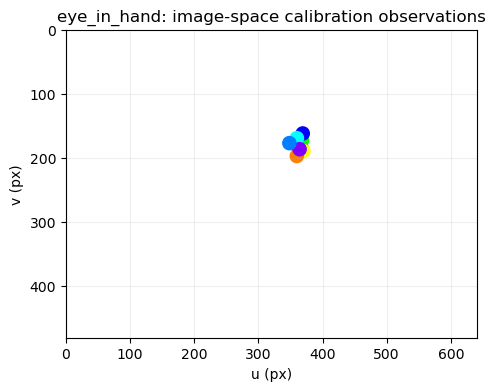

In [7]:
env = PandaEnv(xml_path="scene_eye_in_hand.xml", camera_name="eye_in_hand")
env.reset()
calibration_data = collect_calibration_data_in_hand(env)

Finally, you will implement a hand-eye calibration solver to compute the transformation from the camera frame to the gripper frame.

In [8]:
# ====================================================
# Execute Hand-Eye Calibration (Eye-in-Hand)
# ====================================================

R_c2g_est, t_c2g_est = cv2.calibrateHandEye(
    R_gripper2base=[R for R in calibration_data["R_gripper2base"]],
    t_gripper2base=[t.reshape(3, 1) for t in calibration_data["t_gripper2base"]],
    R_target2cam=[R for R in calibration_data["R_target2cam"]],
    t_target2cam=[t.reshape(3, 1) for t in calibration_data["t_target2cam"]],
    method=cv2.CALIB_HAND_EYE_PARK,
)

In [9]:
# Evaluate against Ground Truth
R_c2g_gt, t_c2g_gt = env.get_gt_hand_eye()
R_err = R_c2g_est @ R_c2g_gt.T
rot_err_deg = np.rad2deg(np.arccos(np.clip((np.trace(R_err) - 1) / 2.0, -1.0, 1.0)))
trans_err = np.linalg.norm(t_c2g_est.reshape(3) - t_c2g_gt.reshape(3))

print("=== Hand-Eye (cam->gripper) ===")
print("Estimated R:\n", R_c2g_est)
print("GT R:\n", R_c2g_gt)
print("Estimated t:", t_c2g_est.reshape(3))
print("GT t:", t_c2g_gt.reshape(3))
print(f"Translation error: {trans_err * 100:.3f} cm")
print(f"Rotation error : {rot_err_deg:.6f} deg")

=== Hand-Eye (cam->gripper) ===
Estimated R:
 [[-2.21300869e-03 -9.64982211e-01 -2.62305993e-01]
 [ 9.99997547e-01 -2.16089529e-03 -4.87132359e-04]
 [-9.67417255e-05 -2.62306428e-01  9.64984626e-01]]
GT R:
 [[-2.30438671e-16 -9.65925668e-01 -2.58819636e-01]
 [ 1.00000000e+00 -2.99237579e-16  6.76668240e-18]
 [-5.61786128e-17 -2.58819636e-01  9.65925668e-01]]
Estimated t: [0.05917529 0.00106317 0.01027278]
GT t: [0.05676475 0.         0.01207407]
Translation error: 0.319 cm
Rotation error : 0.242753 deg


### Rubric

**1. Translation Error (20 Points)**
Based on the printed output `Translation error: X cm`
*   **$\le 0.5$ cm:** 20 pts (Full Credit)
*   **$0.5 < \text{error} \le 1.0$ cm:** 15 pts
*   **$1.0 < \text{error} \le 3.0$ cm:** 10 pts
*   **$3.0 < \text{error} \le 5.0$ cm:** 5 pts
*   **$> 5.0$ cm:** 0 pts

**2. Rotation Error (20 Points)**
Based on the printed output `Rotation error: X deg`
*   **$\le 0.5^\circ$:** 20 pts (Full Credit)
*   **$0.5^\circ < \text{error} \le 1.0^\circ$:** 15 pts
*   **$1.0^\circ < \text{error} \le 3.0^\circ$:** 10 pts
*   **$3.0^\circ < \text{error} \le 5.0^\circ$:** 5 pts
*   **$> 5.0^\circ$:** 0 pts

## Part 3: Eye-to-Hand Calibration

In an Eye-to-Hand setup, the camera is statically mounted in the environment (e.g., on a tripod), while the calibration pattern is held by the robot gripper. We want to find the camera pose relative to the robot's base frame ($T_{cam2base}$).

**You will need to modify the MJCF file ("panda_eye_to_hand.xml") to set up the scene accordingly.**

In [10]:
def collect_calibration_data_to_hand(
    env: PandaEnv, num_poses: int = 15, **kwargs
) -> Dict[str, np.ndarray]:
    """Collect eye-to-hand calibration data via point correspondences + solvePnP."""
    if num_poses <= 0:
        raise ValueError(f"num_poses must be positive, got {num_poses}")

    return _collect_handeye_dataset(
        env,
        num_poses,
        seed=kwargs.get("seed", 2810),
        sample_scale=kwargs.get("sample_scale", 0.22),
        max_attempts=kwargs.get("max_attempts", 5000),
        min_translation_gap=kwargs.get("min_translation_gap", 0.02),
        min_rotation_gap_deg=kwargs.get("min_rotation_gap_deg", 8.0),
        margin=kwargs.get("margin", 20),
        pixel_quantization=kwargs.get("pixel_quantization", PNP_PIXEL_QUANTIZATION),
    )

Collected 15 valid poses in 48 attempts.
Mean solvePnP reprojection RMS: 0.1362 px
Observation sources: {'segmentation': 15}


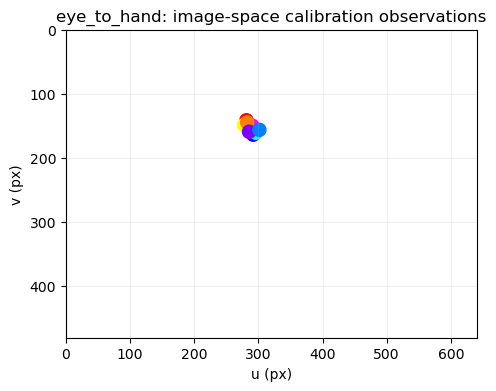

In [11]:
env = PandaEnv(xml_path="scene_eye_to_hand.xml", camera_name="eye_to_hand")
env.reset()
calibration_data = collect_calibration_data_to_hand(env)

In [12]:
# ====================================================
# Execute Hand-Eye Calibration (Eye-to-Hand)
# ====================================================

R_base2gripper = []
t_base2gripper = []
for R_gripper2base, t_gripper2base in zip(
    calibration_data["R_gripper2base"], calibration_data["t_gripper2base"]
):
    R_inv, t_inv = pose_inverse(R_gripper2base, t_gripper2base)
    R_base2gripper.append(R_inv)
    t_base2gripper.append(t_inv.reshape(3, 1))

R_c2b_est, t_c2b_est = cv2.calibrateHandEye(
    R_gripper2base=R_base2gripper,
    t_gripper2base=t_base2gripper,
    R_target2cam=[R for R in calibration_data["R_target2cam"]],
    t_target2cam=[t.reshape(3, 1) for t in calibration_data["t_target2cam"]],
    method=cv2.CALIB_HAND_EYE_PARK,
)

In [13]:
# Evaluate against Ground Truth
R_c2b_gt, t_c2b_gt = env._camera_pose_from_sim()
R_err = R_c2b_est @ R_c2b_gt.T
rot_err_deg = np.rad2deg(np.arccos(np.clip((np.trace(R_err) - 1) / 2.0, -1.0, 1.0)))
trans_err = np.linalg.norm(t_c2b_est.reshape(3) - t_c2b_gt.reshape(3))

print("=== Eye-to-Hand (cam->base) ===")
print("Estimated R:\n", R_c2b_est)
print("GT R:\n", R_c2b_gt)
print("Estimated t:", t_c2b_est.reshape(3))
print("GT t:", t_c2b_gt.reshape(3))
print(f"Translation error: {trans_err * 100:.3f} cm")
print(f"Rotation error : {rot_err_deg:.6f} deg")

=== Eye-to-Hand (cam->base) ===
Estimated R:
 [[ 0.96752292  0.0480418  -0.24817612]
 [ 0.25277697 -0.1769187   0.95121164]
 [ 0.00179092 -0.98305227 -0.18331676]]
GT R:
 [[ 9.66697954e-01  4.65691344e-02 -2.51647335e-01]
 [ 2.55920037e-01 -1.75907629e-01  9.50558489e-01]
 [ 2.77555756e-17 -9.83304542e-01 -1.81967519e-01]]
Estimated t: [ 0.79682831 -1.20318822  0.69885018]
GT t: [ 0.8 -1.2  0.7]
Translation error: 0.464 cm
Rotation error : 0.226727 deg


### Rubric

**1. Translation Error (15 Points)**
Based on the printed output `Translation error: X cm`
*   **$\le 1.0$ cm:** 15 pts (Full Credit)
*   **$1.0 < \text{error} \le 3.0$ cm:** 10 pts
*   **$3.0 < \text{error} \le 5.0$ cm:** 5 pts
*   **$> 5.0$ cm:** 0 pts

**2. Rotation Error (15 Points)**
Based on the printed output `Rotation error: X deg`
*   **$\le 1.0^\circ$:** 15 pts (Full Credit)
*   **$1.0^\circ < \text{error} \le 3.0^\circ$:** 10 pts
*   **$3.0^\circ < \text{error} \le 5.0^\circ$:** 5 pts
*   **$> 5.0^\circ$:** 0 pts

## Submission Notes

### Implementation Summary

**Part 1 (IK).** I implemented a Jacobian-based numerical IK solver for the Panda arm using MuJoCo's site Jacobian (`mj_jacSite`) and damped least-squares updates. To improve robustness, I use multiple restart seeds and clamp the solution to joint limits after each update.

**Part 2 (Eye-in-Hand).** I added a custom 3x3 calibration target in `scene_eye_in_hand.xml`. For each sampled robot pose, I observe the known 3D target points in image space (using rendered marker detection from segmentation/RGB images), then recover `R_target2cam, t_target2cam` with `cv2.solvePnP`. These pose estimates are used in `cv2.calibrateHandEye` to solve for `T_cam2gripper`.

**Part 3 (Eye-to-Hand).** I created `panda_eye_to_hand.xml` and mounted the same calibration target on the gripper while keeping the external camera fixed in `scene_eye_to_hand.xml`. As in Part 2, target-to-camera poses are estimated from rendered image-space point observations with `cv2.solvePnP`, then fed into `cv2.calibrateHandEye` together with the inverted gripper poses to solve for `T_cam2base`.

### References

1. MuJoCo API reference for Jacobians and pose utilities:
   https://mujoco.readthedocs.io/en/latest/APIreference/APIfunctions.html
2. `dm_control` inverse kinematics utility (Jacobian-based numerical IK reference):
   https://github.com/google-deepmind/dm_control/blob/main/dm_control/utils/inverse_kinematics.py
3. MuJoCo discussion on inverse kinematics / Jacobian-based approaches:
   https://github.com/google-deepmind/mujoco/discussions/378
4. Kevin Zakka's MuJoCo differential IK examples (the notebook also hints at this reference):
   https://github.com/kevinzakka/mjctrl
5. OpenCV hand-eye calibration and PnP documentation:
   https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html
